# Day 5: Supervised Learning II — Classification

**Dataset:** Titanic cleaned (from Day 2)
**Target:** `survived` (binary: 0=died, 1=survived)
**Goal:** Logistic Regression, Decision Tree + ROC analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (roc_curve, roc_auc_score, precision_recall_fscore_support,
                             accuracy_score, confusion_matrix, classification_report)
from sklearn.pipeline import Pipeline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

# Load cleaned data
df = pd.read_csv('../data/titanic_clean.csv')
print(f"Loaded: {df.shape}")

Loaded: (891, 19)


In [2]:
# 1. PREPARE FEATURES & TARGET
# Numeric features
numeric_features = ['age', 'sibsp', 'parch', 'family_size', 'fare_per_person', 'pclass', 'is_alone']

# Categorical features to encode
cat_features = ['sex', 'embarked', 'deck', 'who', 'age_bin']

# Create encoded versions
df_encoded = df.copy()
for col in cat_features:
    le = LabelEncoder()
    df_encoded[col + '_encoded'] = le.fit_transform(df_encoded[col].astype(str))

encoded_features = [c + '_encoded' for c in cat_features]
all_features = numeric_features + encoded_features

X = df_encoded[all_features]
y = df_encoded['survived']

# Train/test split (stratified for classification)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Class balance: {y.value_counts().to_dict()}")

Train: (712, 12), Test: (179, 12)
Class balance: {0: 549, 1: 342}


In [3]:
# 2. LOGISTIC REGRESSION
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
lr_pipe.fit(X_train, y_train)

y_pred_lr = lr_pipe.predict(X_test)
y_proba_lr = lr_pipe.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_lr):.4f}")
print(classification_report(y_test, y_pred_lr, target_names=['Died', 'Survived']))

=== Logistic Regression ===
Accuracy:  0.7821
ROC-AUC:   0.8543
              precision    recall  f1-score   support

        Died       0.84      0.80      0.82       110
    Survived       0.70      0.75      0.73        69

    accuracy                           0.78       179
   macro avg       0.77      0.78      0.77       179
weighted avg       0.79      0.78      0.78       179



In [4]:
# 3. DECISION TREE
dt = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

print("=== Decision Tree (max_depth=5) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_dt):.4f}")
print(classification_report(y_test, y_pred_dt, target_names=['Died', 'Survived']))

=== Decision Tree (max_depth=5) ===
Accuracy:  0.7542
ROC-AUC:   0.7735
              precision    recall  f1-score   support

        Died       0.81      0.79      0.80       110
    Survived       0.68      0.70      0.69        69

    accuracy                           0.75       179
   macro avg       0.74      0.74      0.74       179
weighted avg       0.76      0.75      0.75       179



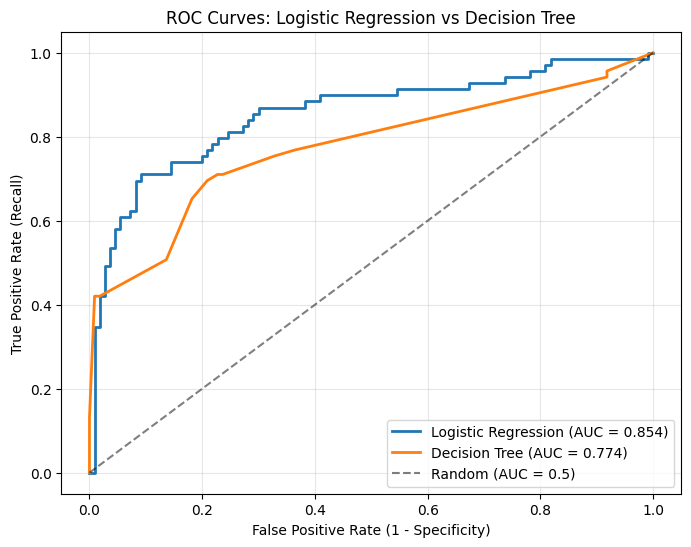

In [5]:
# 4. ROC CURVES
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_proba_lr)
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_proba_dt)

auc_lr = roc_auc_score(y_test, y_proba_lr)
auc_dt = roc_auc_score(y_test, y_proba_dt)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', linewidth=2)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)', alpha=0.5)
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves: Logistic Regression vs Decision Tree')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [6]:
# 5. OPTIMAL THRESHOLD via Youden's J (maximize TPR - FPR)
def optimal_threshold(y_true, y_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    j_scores = tpr - fpr  # Youden's J
    best_idx = np.argmax(j_scores)
    return thresholds[best_idx], j_scores[best_idx]

opt_thresh_lr, j_lr = optimal_threshold(y_test, y_proba_lr)
opt_thresh_dt, j_dt = optimal_threshold(y_test, y_proba_dt)

print(f"Logistic Regression: Optimal threshold = {opt_thresh_lr:.3f}, Youden's J = {j_lr:.3f}")
print(f"Decision Tree: Optimal threshold = {opt_thresh_dt:.3f}, Youden's J = {j_dt:.3f}")

# Evaluate at optimal threshold
y_pred_lr_opt = (y_proba_lr >= opt_thresh_lr).astype(int)
y_pred_dt_opt = (y_proba_dt >= opt_thresh_dt).astype(int)

print("\n=== At Optimal Threshold ===")
print(f"LR - Accuracy: {accuracy_score(y_test, y_pred_lr_opt):.4f}")
print(classification_report(y_test, y_pred_lr_opt, target_names=['Died', 'Survived']))

print(f"DT - Accuracy: {accuracy_score(y_test, y_pred_dt_opt):.4f}")
print(classification_report(y_test, y_pred_dt_opt, target_names=['Died', 'Survived']))

Logistic Regression: Optimal threshold = 0.664, Youden's J = 0.619
Decision Tree: Optimal threshold = 0.527, Youden's J = 0.487

=== At Optimal Threshold ===
LR - Accuracy: 0.8324
              precision    recall  f1-score   support

        Died       0.83      0.91      0.87       110
    Survived       0.83      0.71      0.77        69

    accuracy                           0.83       179
   macro avg       0.83      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179

DT - Accuracy: 0.7542
              precision    recall  f1-score   support

        Died       0.81      0.79      0.80       110
    Survived       0.68      0.70      0.69        69

    accuracy                           0.75       179
   macro avg       0.74      0.74      0.74       179
weighted avg       0.76      0.75      0.75       179



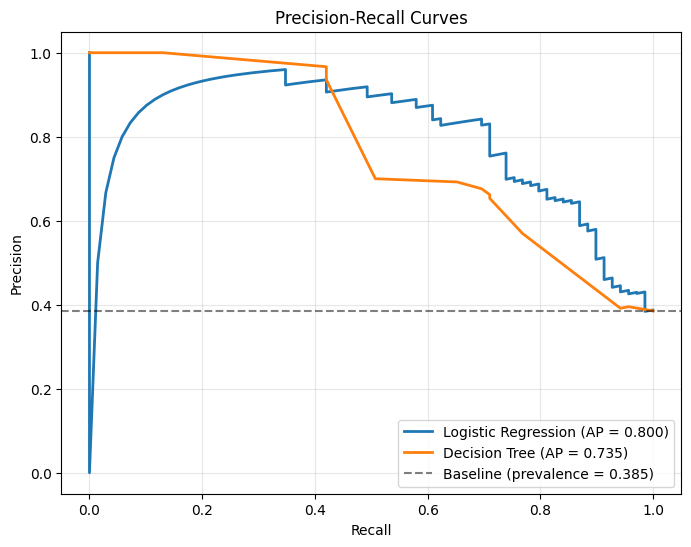

In [7]:
# 6. PRECISION-RECALL CURVE (important for imbalanced data)
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_proba_lr)
precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_proba_dt)

ap_lr = average_precision_score(y_test, y_proba_lr)
ap_dt = average_precision_score(y_test, y_proba_dt)

plt.figure(figsize=(8, 6))
plt.plot(recall_lr, precision_lr, label=f'Logistic Regression (AP = {ap_lr:.3f})', linewidth=2)
plt.plot(recall_dt, precision_dt, label=f'Decision Tree (AP = {ap_dt:.3f})', linewidth=2)
plt.axhline(y=y_test.mean(), color='k', linestyle='--', label=f'Baseline (prevalence = {y_test.mean():.3f})', alpha=0.5)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

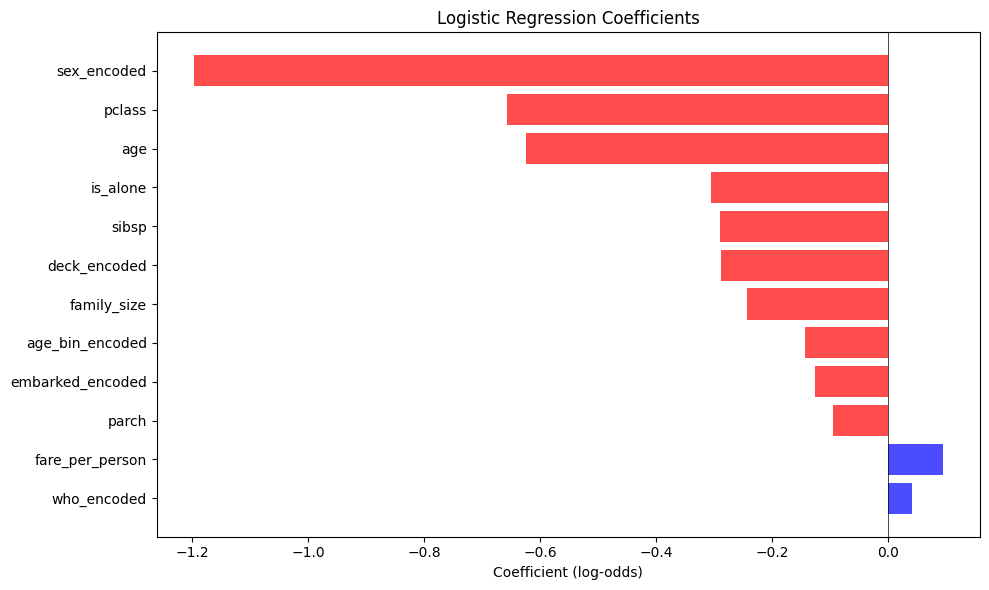

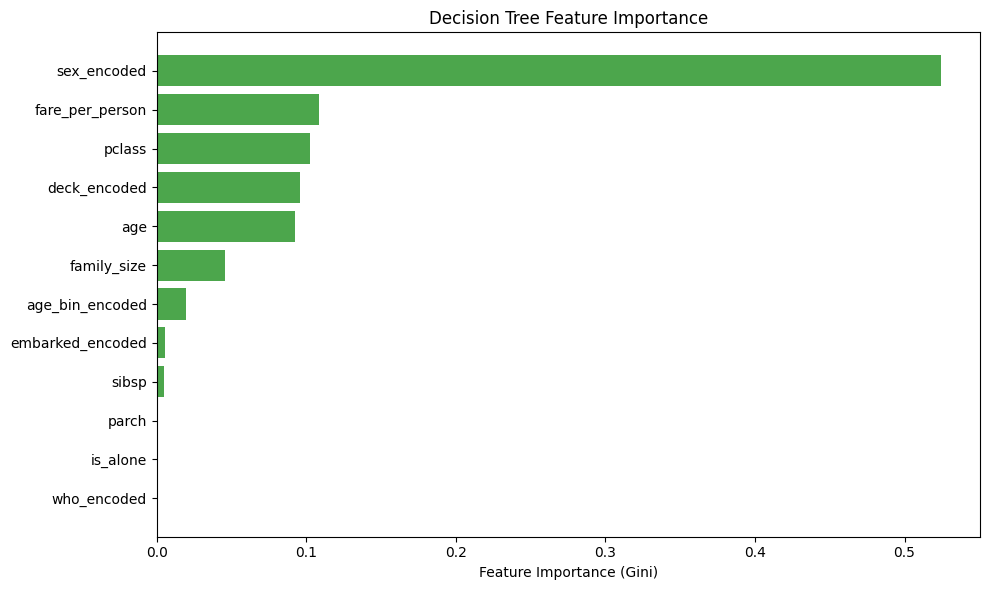

In [8]:
# 7. FEATURE IMPORTANCE / COEFFICIENTS
# Logistic Regression coefficients
lr_coef = lr_pipe.named_steps['lr'].coef_[0]
coef_df = pd.DataFrame({'feature': all_features, 'coefficient': lr_coef})
coef_df = coef_df.sort_values('coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['red' if c < 0 else 'blue' for c in coef_df['coefficient']]
plt.barh(range(len(coef_df)), coef_df['coefficient'], color=colors, alpha=0.7)
plt.yticks(range(len(coef_df)), coef_df['feature'])
plt.xlabel('Coefficient (log-odds)')
plt.title('Logistic Regression Coefficients')
plt.axvline(0, color='black', linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Decision Tree feature importance
dt_importance = pd.DataFrame({'feature': all_features, 'importance': dt.feature_importances_})
dt_importance = dt_importance.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(range(len(dt_importance)), dt_importance['importance'], alpha=0.7, color='green')
plt.yticks(range(len(dt_importance)), dt_importance['feature'])
plt.xlabel('Feature Importance (Gini)')
plt.title('Decision Tree Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Summary Notes

- Best model (ROC-AUC): 
- Optimal thresholds: 
- Key features for survival: 
- Why accuracy is misleading here: 